#  <center> Speech Emotion Recognition <center>

### I am going to build a speech emotion detection classifier.
### But first we need to learn about what is speech recognition (SER) and why are we building this project? Well, few of the reasons are-

#### First, lets define SER i.e. Speech Emotion Recognition.
* Speech Emotion Recognition, abbreviated as SER, is the act of attempting to recognize human emotion and affective states from speech. This is capitalizing on the fact that voice often reflects underlying emotion through tone and pitch. This is also the phenomenon that animals like dogs and horses employ to be able to understand human emotion.

#### Why we need it?

1. Emotion recognition is the part of speech recognition which is gaining more popularity and need for it increases enormously. Although there are methods to recognize emotion using machine learning techniques, this project attempts to use deep learning to recognize the emotions from data.

2. SER(Speech Emotion Recognition) is used in call center for classifying calls according to emotions and can be used as the performance parameter for conversational analysis thus identifying the unsatisfied customer, customer satisfaction and so on.. for helping companies improving their services

3. It can also be used in-car board system based on information of the mental state of the driver can be provided to the system to initiate his/her safety preventing accidents to happen

#### Datasets used in this project

* Crowd-sourced Emotional Mutimodal Actors Dataset (Crema-D)
* Ryerson Audio-Visual Database of Emotional Speech and Song (Ravdess)
* Surrey Audio-Visual Expressed Emotion (Savee)
* Toronto emotional speech set (Tess)

# Importing Libraries

In [ ]:
# ========== BASIC ==========
import numpy as np
import pandas as pd
import os
import sys

# ========== AUDIO ==========
import librosa
import librosa.display

# ========== VISUALIZATION ==========
import seaborn as sns
import matplotlib.pyplot as plt

# ========== SKLEARN ==========
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# ========== AUDIO PLAY ==========
from IPython.display import Audio

# ========== DEEP LEARNING (UPDATED TO TENSORFLOW.KERAS) ==========
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical

# ========== WARNINGS ==========
import warnings
warnings.filterwarnings("ignore")

## Data Preparation
* As we are working with four different datasets, so i will be creating a dataframe storing all emotions of the data in dataframe with their paths.
* We will use this dataframe to extract features for our model training.

In [ ]:
# Paths for data.
Ravdess = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/"
Crema = "/kaggle/input/cremad/AudioWAV/"
Tess = "/kaggle/input/toronto-emotional-speech-set-tess/tess toronto emotional speech set data/TESS Toronto emotional speech set data/"
Savee = "/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['IMG-20231021-WA0213.jpg', 'Kaagaz_20231202_19205841271.pdf', 'Classroom', 'maths.pdf', 'payment.pdf', 'c++ 5th hw.docx', 'Supratik_Roy_Choudhury.png', 'CSE_10900123167_33_SUPRATIK ROY CHOUDHURY .pdf', 'Frontend-Collection', 'Late fine', 'Supratik_Roy_Choudhury_.png', 'Contact Information (1).gform', 'Contact Information (Responses) (2).gsheet', 'Contact Information (Responses) (1).gsheet', 'Contact Information.gform', 'Contact Information (Responses).gsheet', 'Untitled Diagram (7).drawio', '6f89bccb-d42e-48f7-9b02-1cd6679339df.pdf', 'pw receipt.pdf', 'Dsa.pdf', 'Document from Lone Traveller😇😇.pdf', 'pic.jpg', 'Certificate(VAT).pdf', 'CO_part3_2023.pdf.gdrive', 'CA.pdf', 'Kaagaz_20250307_162232540307.pdf', '1090012367.pdf', 'Document from Hi.pdf', 'SBH-2025 (Senior)(final) (3).pdf', 'SBH-2025 (Senior.final).pdf', 'SBH CONCENT LETTER ORIGINAL .pdf', 'Colab Notebooks', 'Image_classification.zip', 'Untitled Diagram (2).drawio.png', 'solve it.gsheet', 'Untitled Diagram (6).drawio', 'Untit

In [ ]:
print(os.listdir('/content/drive/MyDrive/datasets'))

['TESS.zip', 'CREMAD.zip', 'RAVDESS.zip']


In [ ]:
zip_path1 = '/content/drive/MyDrive/datasets/TESS.zip'
zip_path2 = '/content/drive/MyDrive/datasets/RAVDESS.zip'
zip_path3 = '/content/drive/MyDrive/datasets/CREMAD.zip'


In [ ]:
import zipfile
import os

extract_path_1 = '/content/tess_dataset'
extract_path_2 = '/content/ravdess_dataset'
extract_path_3 = '/content/crema_dataset'

with zipfile.ZipFile(zip_path1, 'r') as zip_ref:
    zip_ref.extractall(extract_path_1)
with zipfile.ZipFile(zip_path2 , 'r') as zip_ref:
    zip_ref.extractall(extract_path_2)
with zipfile.ZipFile(zip_path3, 'r') as zip_ref:
    zip_ref.extractall(extract_path_3)


In [ ]:

print(os.listdir(extract_path_1))
print(os.listdir(extract_path_2))
print(os.listdir(extract_path_3))

['TESS Toronto emotional speech set data', 'tess toronto emotional speech set data']
['Actor_09', 'Actor_02', 'Actor_12', 'Actor_16', 'Actor_14', 'Actor_15', 'Actor_23', 'audio_speech_actors_01-24', 'Actor_06', 'Actor_11', 'Actor_05', 'Actor_20', 'Actor_24', 'Actor_13', 'Actor_21', 'Actor_07', 'Actor_08', 'Actor_10', 'Actor_01', 'Actor_19', 'Actor_17', 'Actor_04', 'Actor_18', 'Actor_22', 'Actor_03']
['AudioWAV']


In [ ]:
tess_path = os.path.join(extract_path_1, os.listdir(extract_path_1)[0])

print(os.listdir(tess_path))

['YAF_disgust', 'OAF_Fear', 'OAF_Sad', 'YAF_angry', 'OAF_disgust', 'OAF_neutral', 'OAF_Pleasant_surprise', 'OAF_angry', 'YAF_fear', 'OAF_happy', 'YAF_sad', 'YAF_neutral', 'YAF_pleasant_surprised', 'YAF_happy']


In [ ]:
TESS = extract_path_1
RAVDESS = extract_path_2
CREMA = extract_path_3

In [ ]:
import os

print("TESS:", os.listdir(TESS))
print("RAVDESS:", os.listdir(RAVDESS)[:5])
print("CREMA:", os.listdir(CREMA)[:5])

TESS: ['TESS Toronto emotional speech set data', 'tess toronto emotional speech set data']
RAVDESS: ['Actor_09', 'Actor_02', 'Actor_12', 'Actor_16', 'Actor_14']
CREMA: ['AudioWAV']


##  <center> 1. Ravdess Dataframe <center>
Here is the filename identifiers as per the official RAVDESS website:

* Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
* Vocal channel (01 = speech, 02 = song).
* Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
* Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
* Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
* Repetition (01 = 1st repetition, 02 = 2nd repetition).
* Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

So, here's an example of an audio filename. 02-01-06-01-02-01-12.mp4
This means the meta data for the audio file is:

* Video-only (02)
* Speech (01)
* Fearful (06)
* Normal intensity (01)
* Statement "dogs" (02)
* 1st Repetition (01)
* 12th Actor (12) - Female (as the actor ID number is even)

In [ ]:
import os
import pandas as pd

ravdess_directory_list = os.listdir(RAVDESS)

file_emotion = []
file_path = []

for dir in ravdess_directory_list:

    actor_path = os.path.join(RAVDESS, dir)

    # skip if not a directory
    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):
        if file.endswith('.wav'):

            full_path = os.path.join(actor_path, file)

            # extract emotion
            part = file.split('.')[0]
            part = part.split('-')

            emotion = int(part[2])

            file_emotion.append(emotion)
            file_path.append(full_path)

# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files
path_df = pd.DataFrame(file_path, columns=['Path'])

Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

# map emotions
Ravdess_df['Emotions'] = Ravdess_df['Emotions'].replace({
    1: 'neutral',
    2: 'calm',
    3: 'happy',
    4: 'sad',
    5: 'angry',
    6: 'fear',
    7: 'disgust',
    8: 'surprise'
})

Ravdess_df.head()

,Emotions,Path
0,surprise,/content/ravdess_dataset/Actor_09/03-01-08-02-...
1,calm,/content/ravdess_dataset/Actor_09/03-01-02-02-...
2,disgust,/content/ravdess_dataset/Actor_09/03-01-07-02-...
3,happy,/content/ravdess_dataset/Actor_09/03-01-03-02-...
4,neutral,/content/ravdess_dataset/Actor_09/03-01-01-01-...


## <center>2. Crema DataFrame</center>

In [ ]:
import os
import pandas as pd

crema_directory_list = os.listdir(CREMA)

file_emotion = []
file_path = []

for file in crema_directory_list:

    full_path = os.path.join(CREMA, file)

    # skip if not a wav file
    if not file.endswith('.wav'):
        continue

    # store path
    file_path.append(full_path)

    # extract emotion
    part = file.split('_')

    if len(part) > 2:
        if part[2] == 'SAD':
            file_emotion.append('sad')
        elif part[2] == 'ANG':
            file_emotion.append('angry')
        elif part[2] == 'DIS':
            file_emotion.append('disgust')
        elif part[2] == 'FEA':
            file_emotion.append('fear')
        elif part[2] == 'HAP':
            file_emotion.append('happy')
        elif part[2] == 'NEU':
            file_emotion.append('neutral')
        else:
            file_emotion.append('unknown')
    else:
        file_emotion.append('unknown')

# dataframe for emotion
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path
path_df = pd.DataFrame(file_path, columns=['Path'])

Crema_df = pd.concat([emotion_df, path_df], axis=1)

Crema_df.head(4)

,Emotions,Path


##  <center> 3. TESS dataset <center>

In [ ]:
import os
import pandas as pd

# if there's an extra folder inside, fix it
if len(os.listdir(TESS)) == 1:
    TESS = os.path.join(TESS, os.listdir(TESS)[0])

file_emotion = []
file_path = []

for root, dirs, files in os.walk(TESS):

    for file in files:
        if file.endswith('.wav'):

            full_path = os.path.join(root, file)
            file_path.append(full_path)

            # extract emotion from folder name
            emotion = root.split('/')[-1].lower()

            # clean emotion names (TESS has long labels sometimes)
            if 'angry' in emotion:
                file_emotion.append('angry')
            elif 'disgust' in emotion:
                file_emotion.append('disgust')
            elif 'fear' in emotion:
                file_emotion.append('fear')
            elif 'happy' in emotion:
                file_emotion.append('happy')
            elif 'sad' in emotion:
                file_emotion.append('sad')
            elif 'neutral' in emotion:
                file_emotion.append('neutral')
            else:
                file_emotion.append('unknown')

# dataframe for emotion
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path
path_df = pd.DataFrame(file_path, columns=['Path'])

Tess_df = pd.concat([emotion_df, path_df], axis=1)

Tess_df.head()

,Emotions,Path
0,disgust,/content/tess_dataset/TESS Toronto emotional s...
1,disgust,/content/tess_dataset/TESS Toronto emotional s...
2,disgust,/content/tess_dataset/TESS Toronto emotional s...
3,disgust,/content/tess_dataset/TESS Toronto emotional s...
4,disgust,/content/tess_dataset/TESS Toronto emotional s...


##  <center> 4. CREMA-D dataset <center>
The audio files in this dataset are named in such a way that the prefix letters describes the emotion classes as follows:

* 'a' = 'anger'
* 'd' = 'disgust'
* 'f' = 'fear'
* 'h' = 'happiness'
* 'n' = 'neutral'
* 'sa' = 'sadness'
* 'su' = 'surprise'

In [ ]:
# Combine all datasets safely
data_path = pd.concat([Ravdess_df, Crema_df, Tess_df], axis=0, ignore_index=True)

# Normalize emotion labels (VERY IMPORTANT)
data_path['Emotions'] = data_path['Emotions'].str.lower()

data_path['Emotions'].replace({
    'calm': 'neutral',
    'surprise': 'happy'
}, inplace=True)

# Remove unknown / invalid labels if any
data_path = data_path[data_path['Emotions'] != 'unknown']

# Shuffle dataset (important for training)
data_path = data_path.sample(frac=1, random_state=42).reset_index(drop=True)

# Save CSV
data_path.to_csv("data_path.csv", index=False)

# Preview
data_path.head()

,Emotions,Path
0,sad,/content/tess_dataset/TESS Toronto emotional s...
1,fear,/content/tess_dataset/TESS Toronto emotional s...
2,sad,/content/tess_dataset/tess toronto emotional s...
3,fear,/content/ravdess_dataset/Actor_13/03-01-06-01-...
4,fear,/content/tess_dataset/tess toronto emotional s...


## Data Visualisation and Exploration

First let's plot the count of each emotions in our dataset.

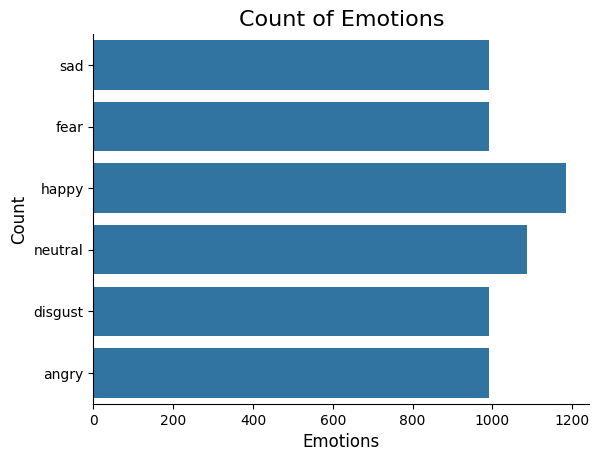

In [ ]:
plt.title('Count of Emotions', size=16)
sns.countplot(data_path.Emotions)
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

We can also plot waveplots and spectograms for audio signals

* Waveplots - Waveplots let us know the loudness of the audio at a given time.
* Spectograms - A spectrogram is a visual representation of the spectrum of frequencies of sound or other signals as they vary with time. It’s a representation of frequencies changing with respect to time for given audio/music signals.

In [ ]:
def create_waveplot(data, sr, e):
    plt.figure(figsize=(10, 3))
    plt.title('Waveplot for audio with {} emotion'.format(e), size=15)
    librosa.display.waveplot(data, sr=sr)
    plt.show()

def create_spectrogram(data, sr, e):
    # stft function converts the data into short term fourier transform
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title('Spectrogram for audio with {} emotion'.format(e), size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
    #librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar()

In [ ]:
def create_waveplot(data, sr, e):
    import matplotlib.pyplot as plt
    import librosa.display

    plt.figure(figsize=(10, 3))
    plt.title(f'Waveplot for audio with {e} emotion', size=15)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

In [ ]:
def create_spectrogram(data, sr, e):
    import matplotlib.pyplot as plt
    import librosa.display
    import numpy as np

    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))

    plt.figure(figsize=(10, 3))
    plt.title(f'Spectrogram for {e} emotion', size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()
    plt.show()

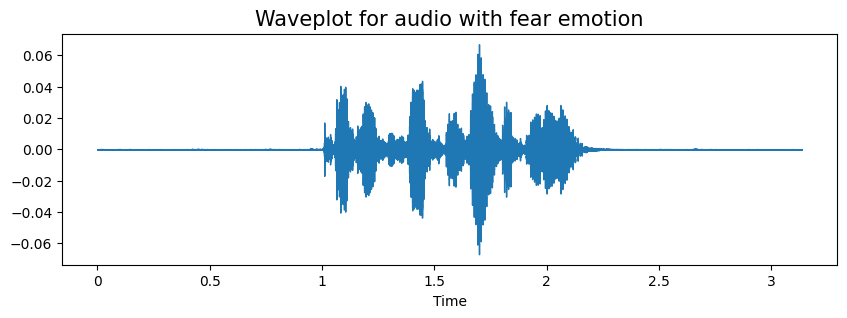

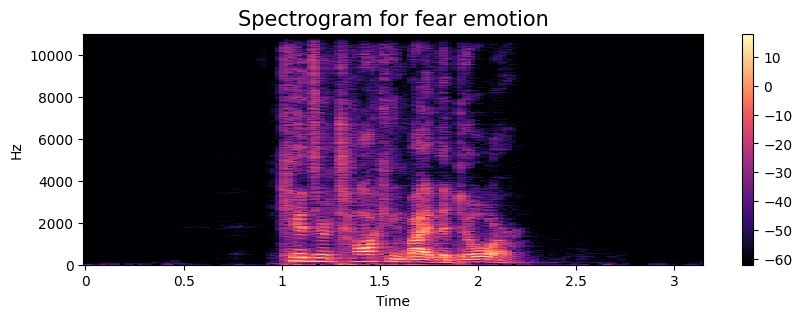

In [ ]:
emotion = 'fear'

path = np.array(data_path.Path[data_path.Emotions == emotion])[1]

data, sampling_rate = librosa.load(path)

create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)

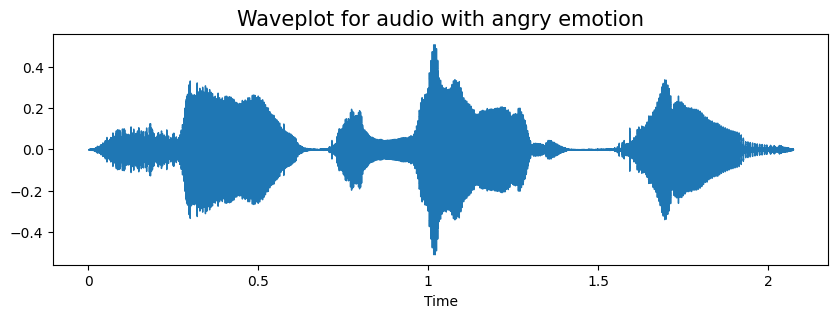

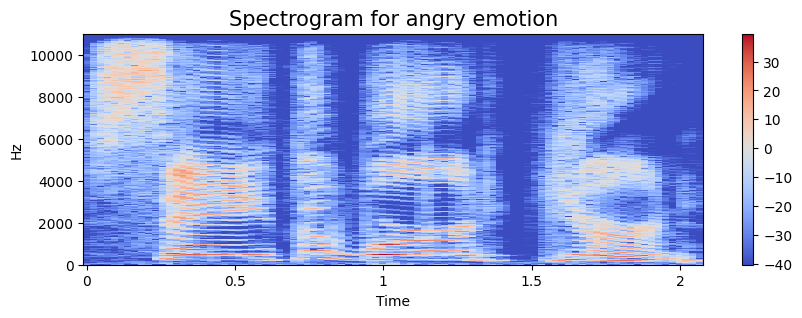

In [ ]:
emotion='angry'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

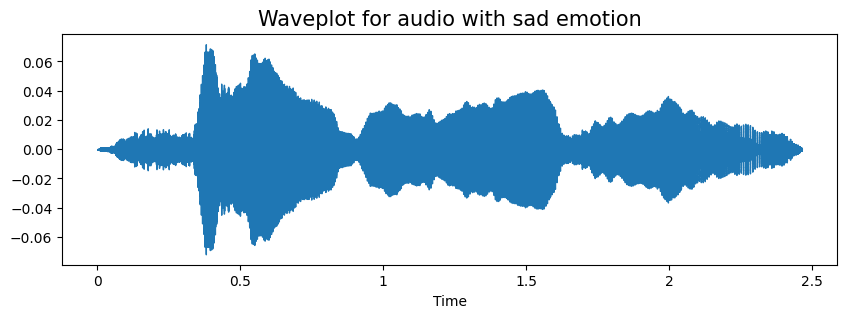

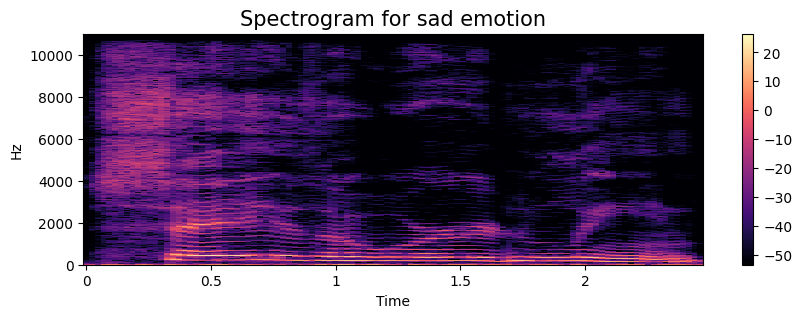

In [ ]:
emotion='sad'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

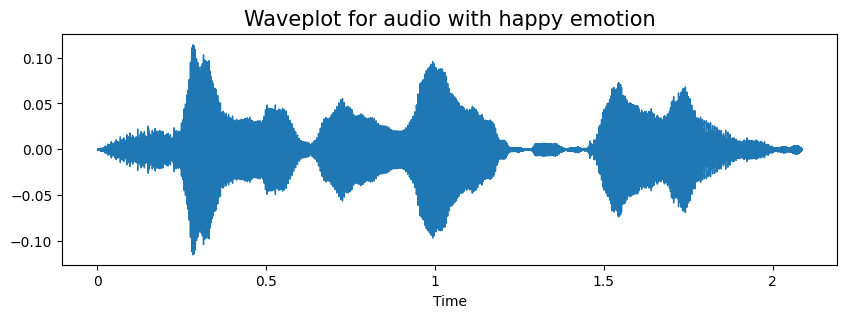

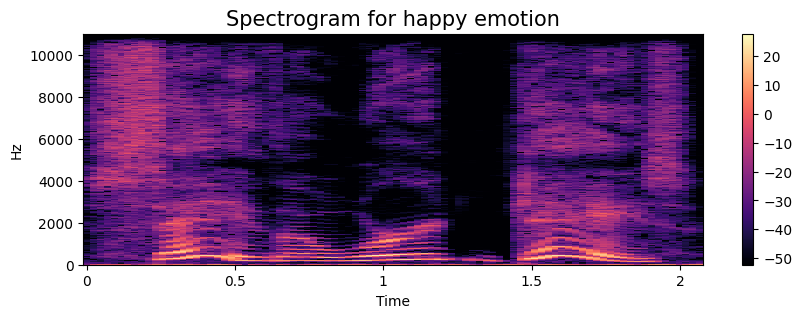

In [ ]:
emotion='happy'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)


## Data Augmentation

- Data augmentation is the process by which we create new synthetic data samples by adding small perturbations on our initial training set.
- To generate syntactic data for audio, we can apply noise injection, shifting time, changing pitch and speed.
- The objective is to make our model invariant to those perturbations and enhace its ability to generalize.
- In order to this to work adding the perturbations must conserve the same label as the original training sample.
- In images data augmention can be performed by shifting the image, zooming, rotating ...

First, let's check which augmentation techniques works better for our dataset.

In [ ]:
def noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sampling_rate, pitch_factor)

# taking any example and checking for techniques.
path = np.array(data_path.Path)[1]
data, sample_rate = librosa.load(path)

#### 1. Simple Audio

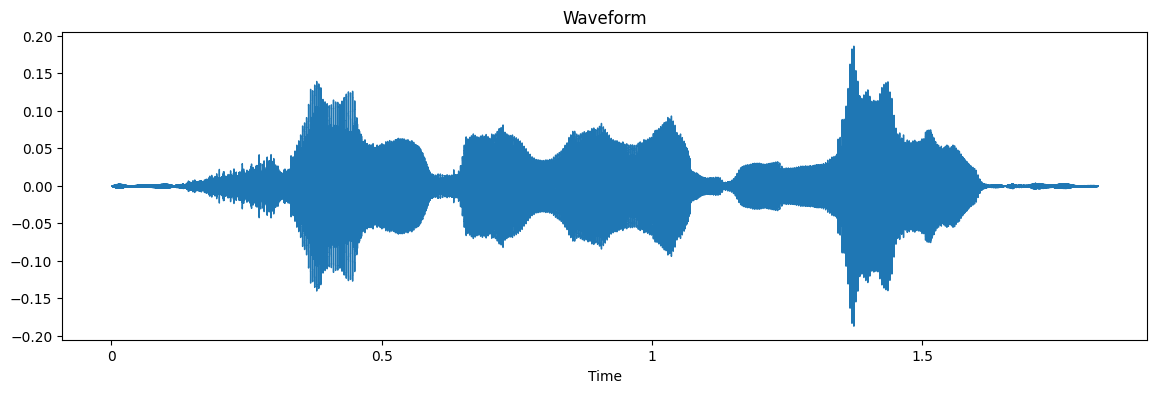

In [ ]:
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio

plt.figure(figsize=(14,4))
librosa.display.waveshow(y=data, sr=sample_rate)
plt.title("Waveform")
plt.show()

Audio(path)

#### 2. Noise Injection

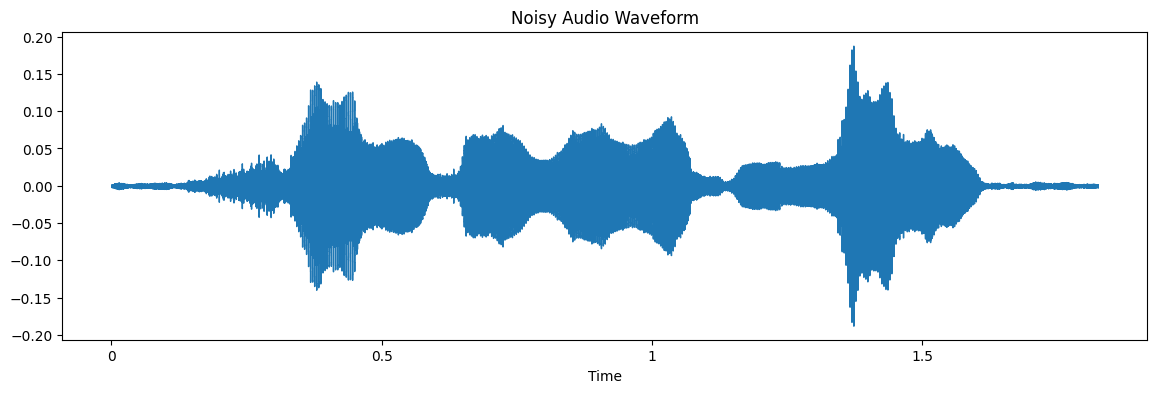

In [ ]:
import librosa.display

x = noise(data)

plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
plt.title("Noisy Audio Waveform")
plt.show()

Audio(x, rate=sample_rate)

We can see noise injection is a very good augmentation technique because of which we can assure our training model is not overfitted

#### 3. Stretching

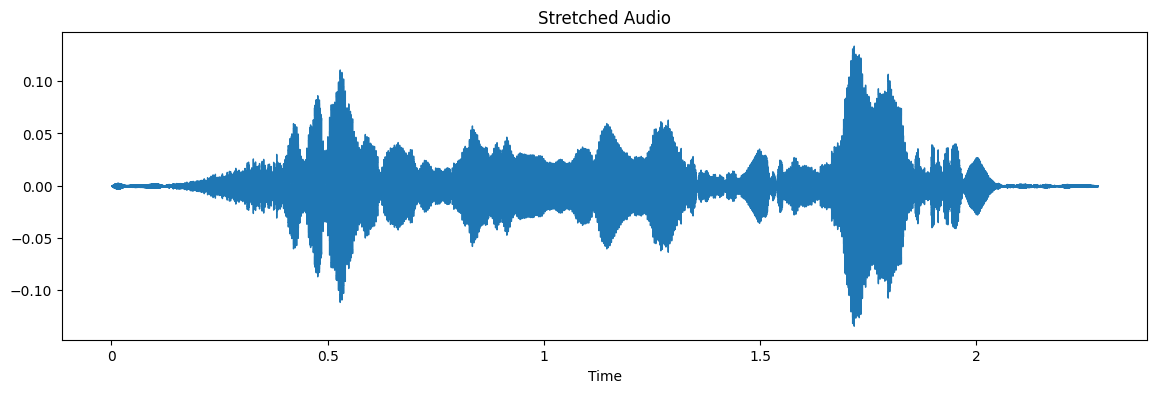

In [ ]:
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio

# stretch function
def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

# apply stretch
x = stretch(data)

# plot
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
plt.title("Stretched Audio")
plt.show()

# play audio
Audio(x, rate=sample_rate)

#### 4. Shifting

#### 5. Pitch

In [118]:
import inspect
print(inspect.getsource(pitch))

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sampling_rate, pitch_factor)



In [119]:
def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(
        y=data,
        sr=sampling_rate,
        n_steps=pitch_factor
    )

In [120]:
import inspect
print(inspect.getsource(pitch))

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(
        y=data,
        sr=sampling_rate,
        n_steps=pitch_factor
    )



- From the above types of augmentation techniques i am using noise, stretching(ie. changing speed) and some pitching.

## Feature Extraction
- Extraction of features is a very important part in analyzing and finding relations between different things. As we already know that the data provided of audio cannot be understood by the models directly so we need to convert them into an understandable format for which feature extraction is used.


The audio signal is a three-dimensional signal in which three axes represent time, amplitude and frequency.

![image.png](https://miro.medium.com/max/633/1*7sKM9aECRmuoqTadCYVw9A.jpeg)

I am no expert on audio signals and feature extraction on audio files so i need to search and found a very good blog written by [Askash Mallik](https://medium.com/heuristics/audio-signal-feature-extraction-and-clustering-935319d2225) on feature extraction.

As stated there with the help of the sample rate and the sample data, one can perform several transformations on it to extract valuable features out of it.
1. Zero Crossing Rate : The rate of sign-changes of the signal during the duration of a particular frame.
2. Energy : The sum of squares of the signal values, normalized by the respective frame length.
3. Entropy of Energy : The entropy of sub-frames’ normalized energies. It can be interpreted as a measure of abrupt changes.
4. Spectral Centroid : The center of gravity of the spectrum.
5. Spectral Spread : The second central moment of the spectrum.
6. Spectral Entropy :  Entropy of the normalized spectral energies for a set of sub-frames.
7. Spectral Flux : The squared difference between the normalized magnitudes of the spectra of the two successive frames.
8. Spectral Rolloff : The frequency below which 90% of the magnitude distribution of the spectrum is concentrated.
9.  MFCCs Mel Frequency Cepstral Coefficients form a cepstral representation where the frequency bands are not linear but distributed according to the mel-scale.
10. Chroma Vector : A 12-element representation of the spectral energy where the bins represent the 12 equal-tempered pitch classes of western-type music (semitone spacing).
11. Chroma Deviation : The standard deviation of the 12 chroma coefficients.


In this project i am not going deep in feature selection process to check which features are good for our dataset rather i am only extracting 5 features:
- Zero Crossing Rate
- Chroma_stft
- MFCC
- RMS(root mean square) value
- MelSpectogram to train our model.

In [121]:
def extract_features(data):
    # ZCR
    result = np.array([])
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result=np.hstack((result, zcr)) # stacking horizontally

    # Chroma_stft
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, chroma_stft)) # stacking horizontally

    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mfcc)) # stacking horizontally

    # Root Mean Square Value
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms)) # stacking horizontally

    # MelSpectogram
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mel)) # stacking horizontally

    return result

def get_features(path):
    # duration and offset are used to take care of the no audio in start and the ending of each audio files as seen above.
    data, sample_rate = librosa.load(path, duration=2.5, offset=0.6)

    # without augmentation
    res1 = extract_features(data)
    result = np.array(res1)

    # data with noise
    noise_data = noise(data)
    res2 = extract_features(noise_data)
    result = np.vstack((result, res2)) # stacking vertically

    # data with stretching and pitching
    new_data = stretch(data)
    data_stretch_pitch = pitch(new_data, sample_rate)
    res3 = extract_features(data_stretch_pitch)
    result = np.vstack((result, res3)) # stacking vertically

    return result

In [122]:
import numpy as np
import librosa

def extract_features(data, sr):
    result = np.array([])

    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)
    result = np.hstack((result, mfcc))

    # Chroma
    stft = np.abs(librosa.stft(data))
    chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)
    result = np.hstack((result, chroma))

    # Mel Spectrogram
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T, axis=0)
    result = np.hstack((result, mel))

    return result

In [ ]:
def noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.max(data)
    return data + noise_amp * np.random.normal(size=data.shape[0])

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

def pitch(data, sr, pitch_factor=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=pitch_factor)

In [ ]:
def noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.max(data)
    return data + noise_amp * np.random.normal(size=data.shape[0])

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

def pitch(data, sr, pitch_factor=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=pitch_factor)

In [123]:
def get_features(path):
    data, sr = librosa.load(path, duration=2.5, offset=0.6)

    result = []

    # original
    res1 = extract_features(data, sr)
    result.append(res1)

    # noise
    noise_data = noise(data)
    res2 = extract_features(noise_data, sr)
    result.append(res2)

    # stretch + pitch
    stretch_data = stretch(data)
    pitch_data = pitch(stretch_data, sr)
    res3 = extract_features(pitch_data, sr)
    result.append(res3)

    return result

In [126]:
X = []
Y = []

for file, label in zip(data_path.Path, data_path.Emotions):

    try:
        data, sr = librosa.load(file, duration=3, offset=0.5)

        feature = extract_features(data, sr)

        X.append(feature)
        Y.append(label)

    except Exception as e:
        print("Error processing:", file)

In [ ]:
for file in data_path.Path:
    feature = extract_features(file)
    X.append(feature)
    Y.append(label)

In [ ]:
len(X), len(Y), data_path.Path.shape

In [128]:
Features = pd.DataFrame(X)
Features['labels'] = Y
Features.to_csv('features.csv', index=False)
Features.head()

,0,1,2,3,4,5,6,7,8,9,...,171,172,173,174,175,176,177,178,179,labels
0,-412.870483,92.849136,23.509888,31.511192,4.902611,7.031099,-4.476438,-15.513373,1.161182,-2.460418,...,0.000095,0.000099,0.000134,0.000153,0.000142,0.000107,0.000149,0.000096,5.888766e-06,sad
1,-456.005188,74.894684,12.581047,0.016708,5.796644,-1.715729,-11.346873,1.552163,-17.871565,-9.210440,...,0.000153,0.000098,0.000135,0.000093,0.000070,0.000054,0.000037,0.000014,1.010863e-06,fear
2,-536.390869,107.043839,38.127243,22.862570,22.656944,9.889188,-9.854595,-8.470773,-18.812447,-7.100593,...,0.000004,0.000003,0.000003,0.000004,0.000005,0.000008,0.000009,0.000004,4.101088e-07,sad
3,-648.967773,65.199486,5.158056,10.940872,8.177052,0.594255,-8.580970,-2.103491,-5.389020,-0.875236,...,0.000008,0.000009,0.000012,0.000017,0.000019,0.000020,0.000012,0.000005,6.886061e-07,fear
4,-437.201935,99.684708,18.776714,-26.016357,-20.166515,2.741236,-4.517896,9.280824,-17.049885,-11.999004,...,0.000184,0.000137,0.000062,0.000106,0.000105,0.000063,0.000028,0.000011,7.926802e-07,fear


* We have applied data augmentation and extracted the features for each audio files and saved them.

## Data Preparation

- As of now we have extracted the data, now we need to normalize and split our data for training and testing.

In [129]:
X = Features.iloc[: ,:-1].values
Y = Features['labels'].values

In [130]:
# As this is a multiclass classification problem onehotencoding our Y.
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()

In [132]:
# splitting data
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((4680, 180), (4680, 6), (1560, 180), (1560, 6))

In [133]:
# scaling our data with sklearn's Standard scaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((4680, 180), (4680, 6), (1560, 180), (1560, 6))

In [134]:
# making our data compatible to model.
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((4680, 180, 1), (4680, 6), (1560, 180, 1), (1560, 6))

## Modelling

In [136]:
model=Sequential()
model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(x_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))
model.add(Dropout(0.2))

model.add(Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Flatten())
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(units=8, activation='softmax'))
model.compile(optimizer = 'adam' , loss = 'categorical_crossentropy' , metrics = ['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 180, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 90, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 90, 256)        │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 45, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 45, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 23, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        24,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,336 (2.13 MB)

 Trainable params: 559,336 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [137]:
print(len(Y[0]))

6


In [138]:
import numpy as np

print(np.array(Y).shape)

(6240, 6)


In [139]:
Dense(6, activation='softmax')

<Dense name=dense_6, built=False>

In [140]:
print(x_train.shape)
print(y_train.shape)

(4680, 180, 1)
(4680, 6)


In [141]:
Dense(num_classes, activation='softmax')

NameError: name 'num_classes' is not defined

In [142]:
print("X_train:", x_train.shape)
print("Y_train:", y_train.shape)

X_train: (4680, 180, 1)
Y_train: (4680, 6)


In [143]:
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout

model = Sequential()

# input shape matches your data
model.add(Conv1D(256, 5, activation='relu', input_shape=(180,1)))
model.add(MaxPooling1D(5))

model.add(Conv1D(128, 5, activation='relu'))
model.add(MaxPooling1D(5))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# 🔥 FINAL LAYER (FIXED)
model.add(Dense(6, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 176, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 35, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 31, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,110 (840.27 KB)

 Trainable params: 215,110 (840.27 KB)

 Non-trainable params: 0 (0.00 B)

In [144]:
print(y_train.shape)
model.summary()

(4680, 6)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 176, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 35, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 31, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,110 (840.27 KB)

 Trainable params: 215,110 (840.27 KB)

 Non-trainable params: 0 (0.00 B)

In [145]:
from keras.callbacks import ReduceLROnPlateau

rlrp = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=2,
    min_lr=1e-7
)

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=[rlrp]
)

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.6440 - loss: 1.0087 - val_accuracy: 0.7885 - val_loss: 0.6512 - learning_rate: 0.0010
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.8145 - loss: 0.5723 - val_accuracy: 0.8269 - val_loss: 0.5096 - learning_rate: 0.0010
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.8393 - loss: 0.4716 - val_accuracy: 0.8410 - val_loss: 0.4471 - learning_rate: 0.0010
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8472 - loss: 0.4422 - val_accuracy: 0.8468 - val_loss: 0.4275 - learning_rate: 0.0010
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.8560 - loss: 0.3951 - val_accuracy: 0.8686 - val_loss: 0.3936 - learning_rate: 0.0010
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.8675 - loss: 0.3676 - val_accuracy: 0.8692 - val_loss: 0.3767 - learning_rate: 0.0010
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 168ms/step - accuracy: 0.8669 - loss: 0.3572 -

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8936 - loss: 0.3191
Accuracy of our model on test data :  89.3589735031128 %


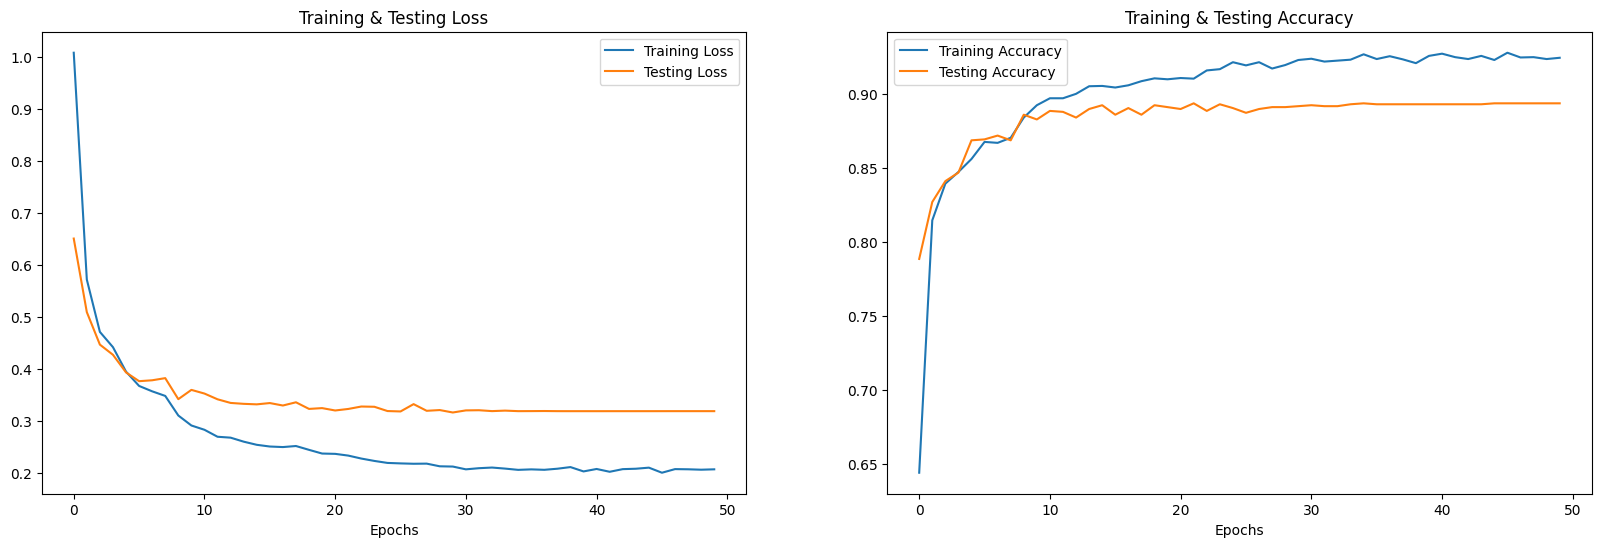

In [148]:
print("Accuracy of our model on test data : " , model.evaluate(x_test,y_test)[1]*100 , "%")

epochs = [i for i in range(50)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
test_acc = history.history['val_accuracy']
test_loss = history.history['val_loss']

fig.set_size_inches(20,6)
ax[0].plot(epochs , train_loss , label = 'Training Loss')
ax[0].plot(epochs , test_loss , label = 'Testing Loss')
ax[0].set_title('Training & Testing Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

ax[1].plot(epochs , train_acc , label = 'Training Accuracy')
ax[1].plot(epochs , test_acc , label = 'Testing Accuracy')
ax[1].set_title('Training & Testing Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")
plt.show()

In [149]:
# predicting on test data.
pred_test = model.predict(x_test)
y_pred = encoder.inverse_transform(pred_test)

y_test = encoder.inverse_transform(y_test)

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [150]:
df = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df['Predicted Labels'] = y_pred.flatten()
df['Actual Labels'] = y_test.flatten()

df.head(10)

,Predicted Labels,Actual Labels
0,neutral,neutral
1,fear,fear
2,disgust,disgust
3,angry,angry
4,sad,sad
5,sad,sad
6,fear,fear
7,happy,happy
8,disgust,disgust
9,angry,angry


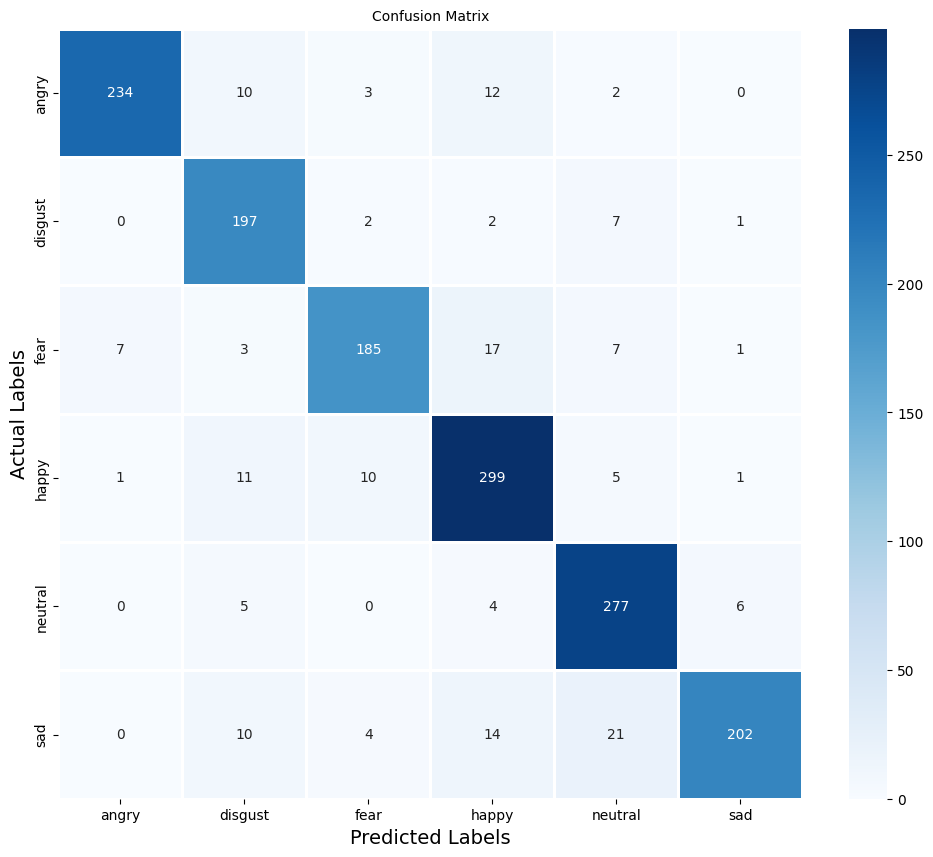

In [156]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (12, 10))
cm = pd.DataFrame(cm , index = [i for i in encoder.categories_] , columns = [i for i in encoder.categories_])
sns.heatmap(cm, linecolor='white', cmap='Blues', linewidth=1, annot=True, fmt='')
plt.title('Confusion Matrix', size=10)
plt.xlabel('Predicted Labels', size=14)
plt.ylabel('Actual Labels', size=14)
plt.show()

In [153]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       angry       0.97      0.90      0.93       261
     disgust       0.83      0.94      0.89       209
        fear       0.91      0.84      0.87       220
       happy       0.86      0.91      0.89       327
     neutral       0.87      0.95      0.91       292
         sad       0.96      0.80      0.87       251

    accuracy                           0.89      1560
   macro avg       0.90      0.89      0.89      1560
weighted avg       0.90      0.89      0.89      1560



In [155]:
import pickle
model.save("emotion_model.keras")

pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(encoder, open("encoder.pkl", "wb"))

- We can see our model is more accurate in predicting surprise, angry emotions and it makes sense also because audio files of these emotions differ to other audio files in a lot of ways like pitch, speed etc..
- We overall achieved 61% accuracy on our test data and its decent but we can improve it more by applying more augmentation techniques and using other feature extraction methods.

### This is all i wanna do in this project. Hope you guyz like this.
### If you like the kernel make sure to upvote it please :-)